In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Dataset tools
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

# Training utilities
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


In [3]:
# Class names for CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display dataset information
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("Image shape:", x_train.shape[1:])
print("Number of classes:", len(class_names))

Number of training images: 50000
Number of test images: 10000
Image shape: (32, 32, 3)
Number of classes: 10


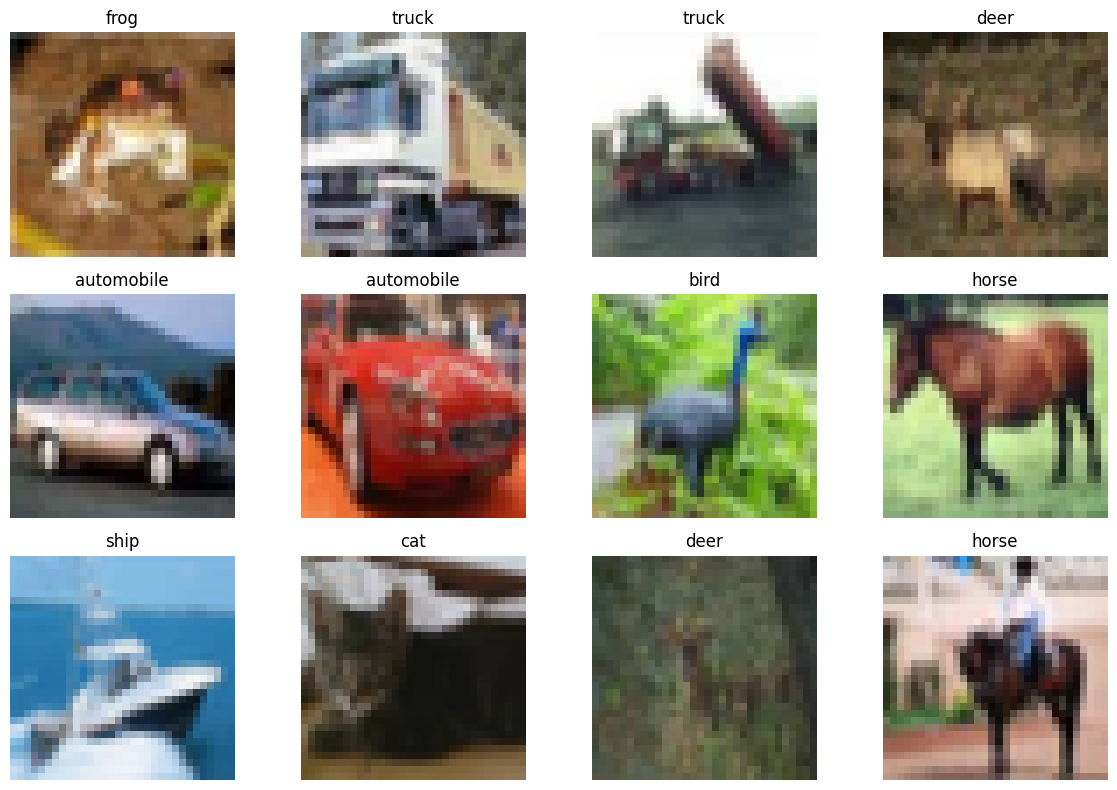

In [4]:
# Show sample images from the dataset
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Count how many images belong to each class in the training set
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{class_names[label]}: {count}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


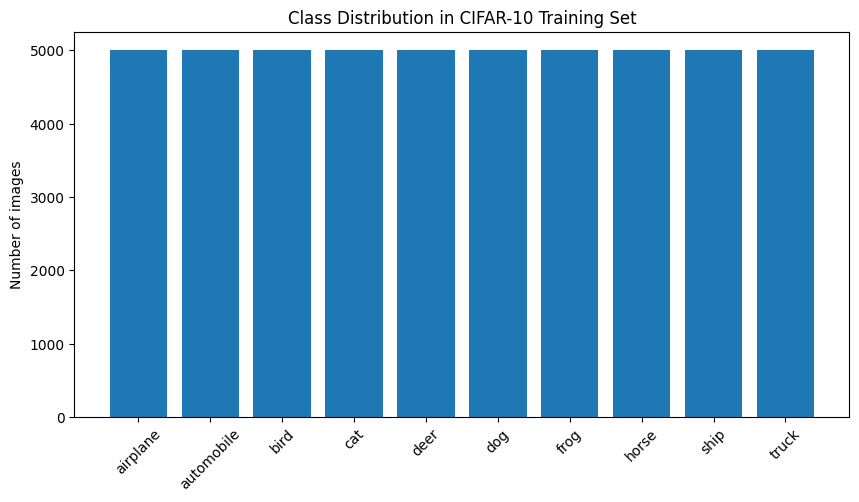

In [6]:
# Plot class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.show()

In [8]:
# Convert images to float32 and scale pixel values to the range [0, 1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

print("Normalized training data shape:", x_train_norm.shape)
print("Normalized test data shape:", x_test_norm.shape)
print("Pixel range after normalization:", x_train_norm.min(), "to", x_train_norm.max())

Normalized training data shape: (50000, 32, 32, 3)
Normalized test data shape: (10000, 32, 32, 3)
Pixel range after normalization: 0.0 to 1.0


In [9]:
# Convert class labels to one-hot encoded format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Original label example:", y_train[0])
print("One-hot encoded label example:", y_train_cat[0])

Original label example: [6]
One-hot encoded label example: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [10]:
# Convert RGB images to grayscale using TensorFlow
x_train_gray = tf.image.rgb_to_grayscale(x_train).numpy()
x_test_gray = tf.image.rgb_to_grayscale(x_test).numpy()

# Normalize grayscale images
x_train_gray = x_train_gray.astype("float32") / 255.0
x_test_gray = x_test_gray.astype("float32") / 255.0

print("Grayscale training shape:", x_train_gray.shape)
print("Grayscale test shape:", x_test_gray.shape)

Grayscale training shape: (50000, 32, 32, 1)
Grayscale test shape: (10000, 32, 32, 1)



grayscale conversion was not selected as the main approach for the final model because CIFAR-10 is a colour-based dataset, and colour information may help distinguish between visually similar classes. For this reason, the final model retained RGB images.

In [11]:
import cv2

# Apply histogram equalisation to grayscale images
x_train_gray_uint8 = (x_train_gray.squeeze() * 255).astype("uint8")
x_test_gray_uint8 = (x_test_gray.squeeze() * 255).astype("uint8")

x_train_he = np.array([cv2.equalizeHist(img) for img in x_train_gray_uint8])
x_test_he = np.array([cv2.equalizeHist(img) for img in x_test_gray_uint8])

# Reshape to add channel dimension back
x_train_he = x_train_he[..., np.newaxis].astype("float32") / 255.0
x_test_he = x_test_he[..., np.newaxis].astype("float32") / 255.0

print("Histogram equalised training shape:", x_train_he.shape)

Histogram equalised training shape: (50000, 32, 32, 1)


Although this method can sometimes improve image quality, it was not chosen as the main preprocessing method for the final CIFAR-10 model. The dataset contains natural images rather than low-contrast medical or grayscale images, so the benefits of histogram equalisation were less certain in this case.

In [12]:
# Apply Gaussian blur to normalized RGB images
x_train_blur = np.array([cv2.GaussianBlur(img, (3, 3), 0) for img in x_train_norm])
x_test_blur = np.array([cv2.GaussianBlur(img, (3, 3), 0) for img in x_test_norm])

print("Blurred training shape:", x_train_blur.shape)

Blurred training shape: (50000, 32, 32, 3)


However, because CIFAR-10 images are already very small, excessive smoothing may remove useful features such as edges and textures. For this reason, Gaussian blur was treated as an optional experimental preprocessing step rather than the main approach.

In [13]:
# Example: reshaping grayscale data for CNN input
x_train_gray_reshaped = x_train_gray.reshape(-1, 32, 32, 1)
x_test_gray_reshaped = x_test_gray.reshape(-1, 32, 32, 1)

print("Reshaped grayscale training data:", x_train_gray_reshaped.shape)

Reshaped grayscale training data: (50000, 32, 32, 1)


For the final RGB model, additional reshaping was not required because the original CIFAR-10 format already matched the expected CNN input shape of 32 × 32 × 3.

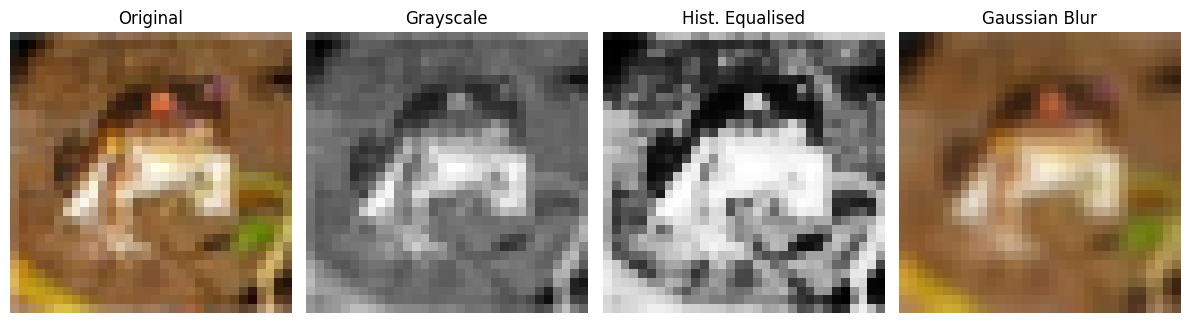

In [14]:
# Compare one original image with preprocessing alternatives
sample_index = 0

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_train[sample_index])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(x_train_gray[sample_index].squeeze(), cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(x_train_he[sample_index].squeeze(), cmap="gray")
plt.title("Hist. Equalised")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(x_train_blur[sample_index])
plt.title("Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training images
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

# No augmentation for validation/test, only rescaling already done earlier
# Using the normalized data prepared before
train_generator = train_datagen.flow(
    x_train_norm,
    y_train_cat,
    batch_size=64,
    subset="training"
)

val_generator = train_datagen.flow(
    x_train_norm,
    y_train_cat,
    batch_size=64,
    subset="validation"
)

print("Training batches:", len(train_generator))
print("Validation batches:", len(val_generator))

Training batches: 625
Validation batches: 157


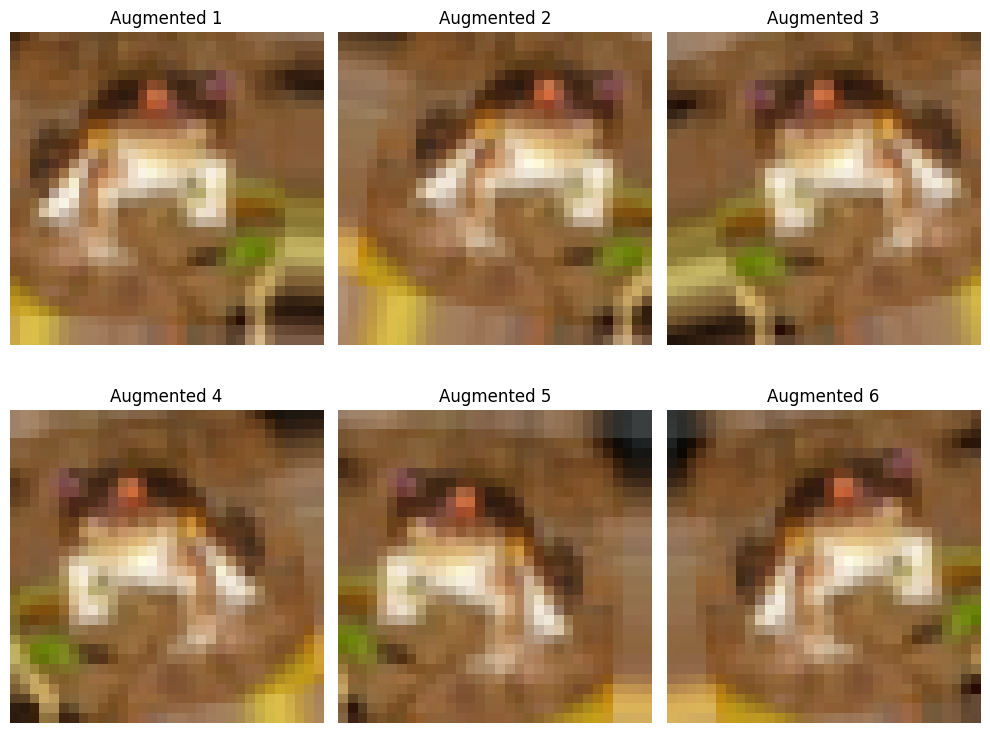

In [17]:
# Display augmented versions of one training image
sample_image = x_train_norm[0].reshape((1, 32, 32, 3))

plt.figure(figsize=(10, 8))

i = 0
for batch in train_datagen.flow(sample_image, batch_size=1):
    plt.subplot(2, 3, i + 1)
    plt.imshow(batch[0])
    plt.axis("off")
    plt.title(f"Augmented {i+1}")
    i += 1
    if i == 6:
        break

plt.tight_layout()
plt.show()

Data augmentation was applied only to the training data and not to the validation or test sets. This ensured that model evaluation was carried out on unchanged images, giving a fair measure of real performance.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Baseline CNN model
baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense (Dense)               (None, 128)             

In [19]:
# Total number of trainable parameters
print("Total parameters:", baseline_model.count_params())

Total parameters: 545098


In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20


625/625 [==============================] - 11s 17ms/step - loss: 1.7460 - accuracy: 0.3620 - val_loss: 1.4344 - val_accuracy: 0.4918
Epoch 2/20
625/625 [==============================] - 10s 16ms/step - loss: 1.4621 - accuracy: 0.4714 - val_loss: 1.2797 - val_accuracy: 0.5400
Epoch 3/20
625/625 [==============================] - 10s 17ms/step - loss: 1.3546 - accuracy: 0.5144 - val_loss: 1.2397 - val_accuracy: 0.5642
Epoch 4/20
625/625 [==============================] - 11s 17ms/step - loss: 1.2803 - accuracy: 0.5443 - val_loss: 1.1657 - val_accuracy: 0.5863
Epoch 5/20
625/625 [==============================] - 11s 17ms/step - loss: 1.2292 - accuracy: 0.5616 - val_loss: 1.1316 - val_accuracy: 0.5975
Epoch 6/20
625/625 [==============================] - 11s 17ms/step - loss: 1.1898 - accuracy: 0.5757 - val_loss: 1.1043 - val_accuracy: 0.6110
Epoch 7/20
625/625 [==============================] - 11s 17ms/step - loss: 1.1576 - accuracy: 0.5887 - val_loss: 1.0727 - val_accurac

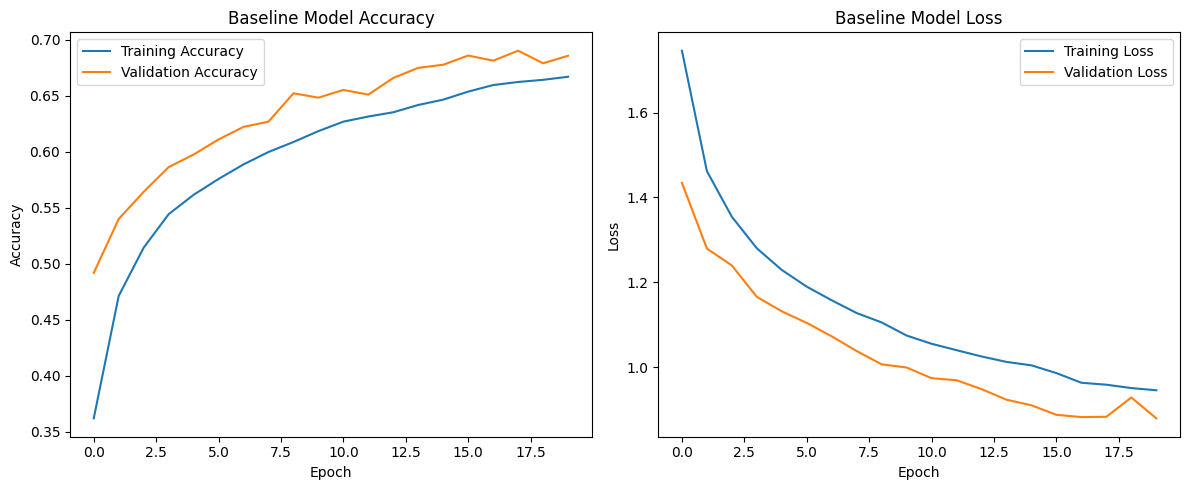

In [21]:
# Plot training and validation accuracy/loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Baseline Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Evaluate the baseline model on the test set
test_loss, test_accuracy = baseline_model.evaluate(x_test_norm, y_test_cat, verbose=0)

print("Baseline Test Loss:", test_loss)
print("Baseline Test Accuracy:", test_accuracy)

Baseline Test Loss: 0.824833869934082
Baseline Test Accuracy: 0.7166000008583069


In [23]:
# Generate predictions on the test set
y_pred_probs = baseline_model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

313/313 [==============================] - 1s 2ms/step


In [24]:
# Print classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.65      0.83      0.73      1000
  automobile       0.72      0.92      0.81      1000
        bird       0.70      0.54      0.61      1000
         cat       0.65      0.43      0.52      1000
        deer       0.73      0.60      0.66      1000
         dog       0.69      0.58      0.63      1000
        frog       0.68      0.88      0.77      1000
       horse       0.70      0.83      0.76      1000
        ship       0.85      0.80      0.82      1000
       truck       0.82      0.75      0.79      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



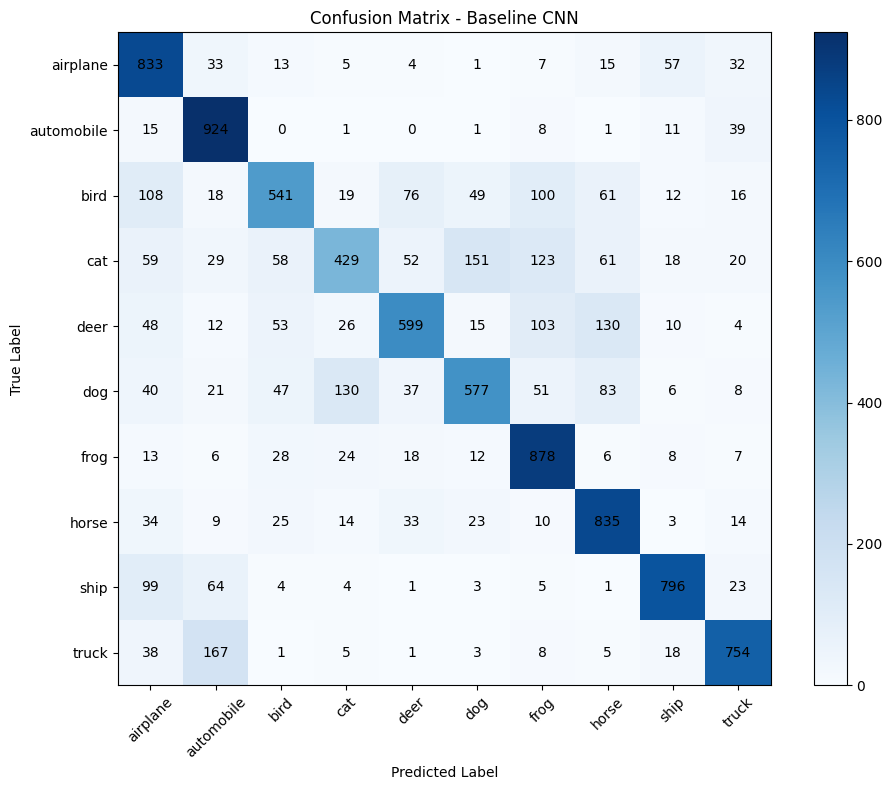

In [25]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Baseline CNN")
plt.colorbar()
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.yticks(ticks=np.arange(len(class_names)), labels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

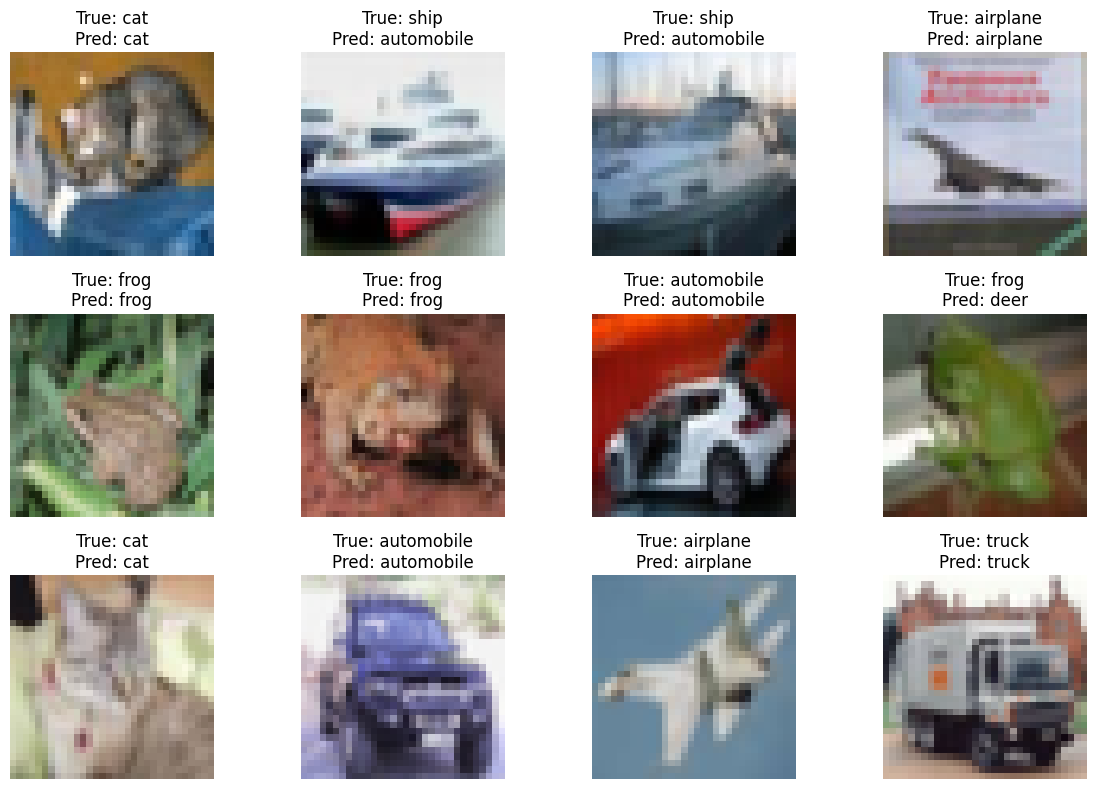

In [26]:
# Display sample predictions
plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

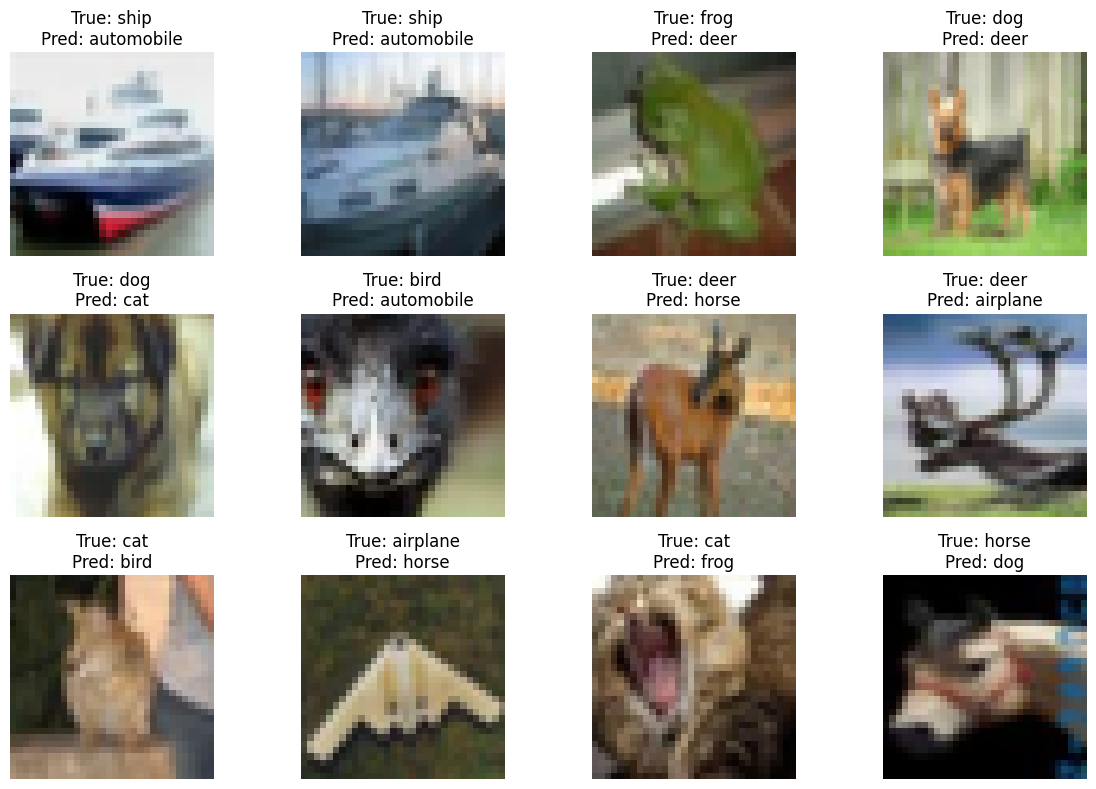

In [27]:
# Show some misclassified images
misclassified = np.where(y_true != y_pred)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()